In [1]:
# Load packages
suppressPackageStartupMessages({
    library(Seurat)
    library(scran)
    library(scater)
    library(batchelor)
    library(SingleCellExperiment)
    library(scater)
    library(Matrix)
    library(reshape2)
    library(data.table)
    library(BiocParallel)
    library(dplyr)
    library(gridExtra)
})

    ncores = 8
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/XXX_test/"
out_dir = paste0(main, '07_atlas_mapping/')
plot_dir = paste0(main, '07_atlas_mapping/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)

source(paste0(main, "mapping_functions.R"))

In [3]:
load_data(normalise=TRUE)
sce_query = sce[Matrix::rowSums(counts(sce)) > 0,]
meta_query = meta

In [17]:
meta_query = meta_query[meta_query$cell %in% sample(meta_query$cell, 1000),]
sce_query = sce_query[,meta_query$cell]

In [18]:
load_atlas_data(normalise=FALSE)
sce_atlas = sce[Matrix::rowSums(counts(sce)) > 0,]
meta_atlas = meta

In [19]:
rm(sce)
rm(meta)

meta_atlas = meta_atlas[meta_atlas$cell %in% sample(meta_atlas$cell, 5000),]
sce_atlas = sce_atlas[,meta_atlas$cell]

In [21]:
# genes shared across datasets
shared_genes = merge(data.frame('V1'=names(sce_atlas)), data.frame('V1'=names(sce_query)), by='V1')

# filter cells & genes chimera dataset
sce_query = sce_query[shared_genes$V1,!c(meta_query$doublet | meta_query$stripped)]
meta_query = meta_query[!c(meta_query$doublet | meta_query$stripped),]

# filter cells & genes atlas dataset
sce_atlas = sce_atlas[shared_genes$V1,!c(meta_atlas$doublet | meta_atlas$stripped)]
meta_atlas = meta_atlas[!c(meta_atlas$doublet | meta_atlas$stripped),]

In [22]:
sce_atlas = logNormCounts(sce_atlas)

In [23]:
sce_atlas
sce_query

class: SingleCellExperiment 
dim: 22059 4170 
metadata(0):
assays(2): counts logcounts
rownames(22059): ENSMUSG00000000001 ENSMUSG00000000028 ...
  ENSMUSG00000114188 ENSMUSG00000114192
rowData names(0):
colnames(4170): cell_12 cell_28 ... cell_139213 cell_139262
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

class: SingleCellExperiment 
dim: 22059 921 
metadata(0):
assays(2): counts logcounts
rownames(22059): ENSMUSG00000000001 ENSMUSG00000000028 ...
  ENSMUSG00000114188 ENSMUSG00000114192
rowData names(0):
colnames(921): cell_19 cell_54 ... cell_30143 cell_30147
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

In [24]:
a = Sys.time()
mappings = lapply(unique(meta_query$sample), function(x){
    print(x)
    mapWrap(
        atlas_sce = sce_atlas, 
        atlas_meta = meta_atlas,
        map_sce = sce_query[, meta_query$sample == x], 
        map_meta = meta_query[meta_query$sample == x,], 
        # genes = marker_genes, 
        npcs = 20, 
        k = 30)$mapping
})
                  
mappings = do.call(rbind, mappings)
b = Sys.time()
paste0('non-parallel time: ')
print(b - a)

[1] 3


Normalizing joint dataset...

Done


Genes not provided. Computing highly variable genes...

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Done


Performing PCA...

Done


Batch effect correction for the atlas...

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' ca

[1] 8


Normalizing joint dataset...

Done


Genes not provided. Computing highly variable genes...

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Done


Performing PCA...

Done


Batch effect correction for the atlas...

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRU

[1] 4


...

Normalizing joint dataset...

Done


Genes not provided. Computing highly variable genes...

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Done


Performing PCA...

Done


Batch effect correction for the atlas...

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' ca

[1] 7


Normalizing joint dataset...

Done


Genes not provided. Computing highly variable genes...

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“collapsing to unique 'x' values”
Done


Performing PCA...

Done


Batch effect correction for the atlas...

Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRUE):
“'k' capped at the number of observations”
Warning message in .refine_k(k, precomputed, query = TRU

[1] "non-parallel time: "

Time difference of 3.510138 mins


In [135]:
write.csv(mappings, file =  paste0(out_dir,"mapped.csv"),row.names=FALSE)

In [136]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

In [137]:
atlas_meta = meta_atlas
atlas_umap <- atlas_meta[, c('cell', 'umapX', 'umapY')]
mappings = merge(mappings, atlas_umap, by.x='closest.cell', by.y='cell')

query_tdtom = meta_query[, c('cell', 'tdTom')]
mappings = merge(mappings, query_tdtom, by='cell')

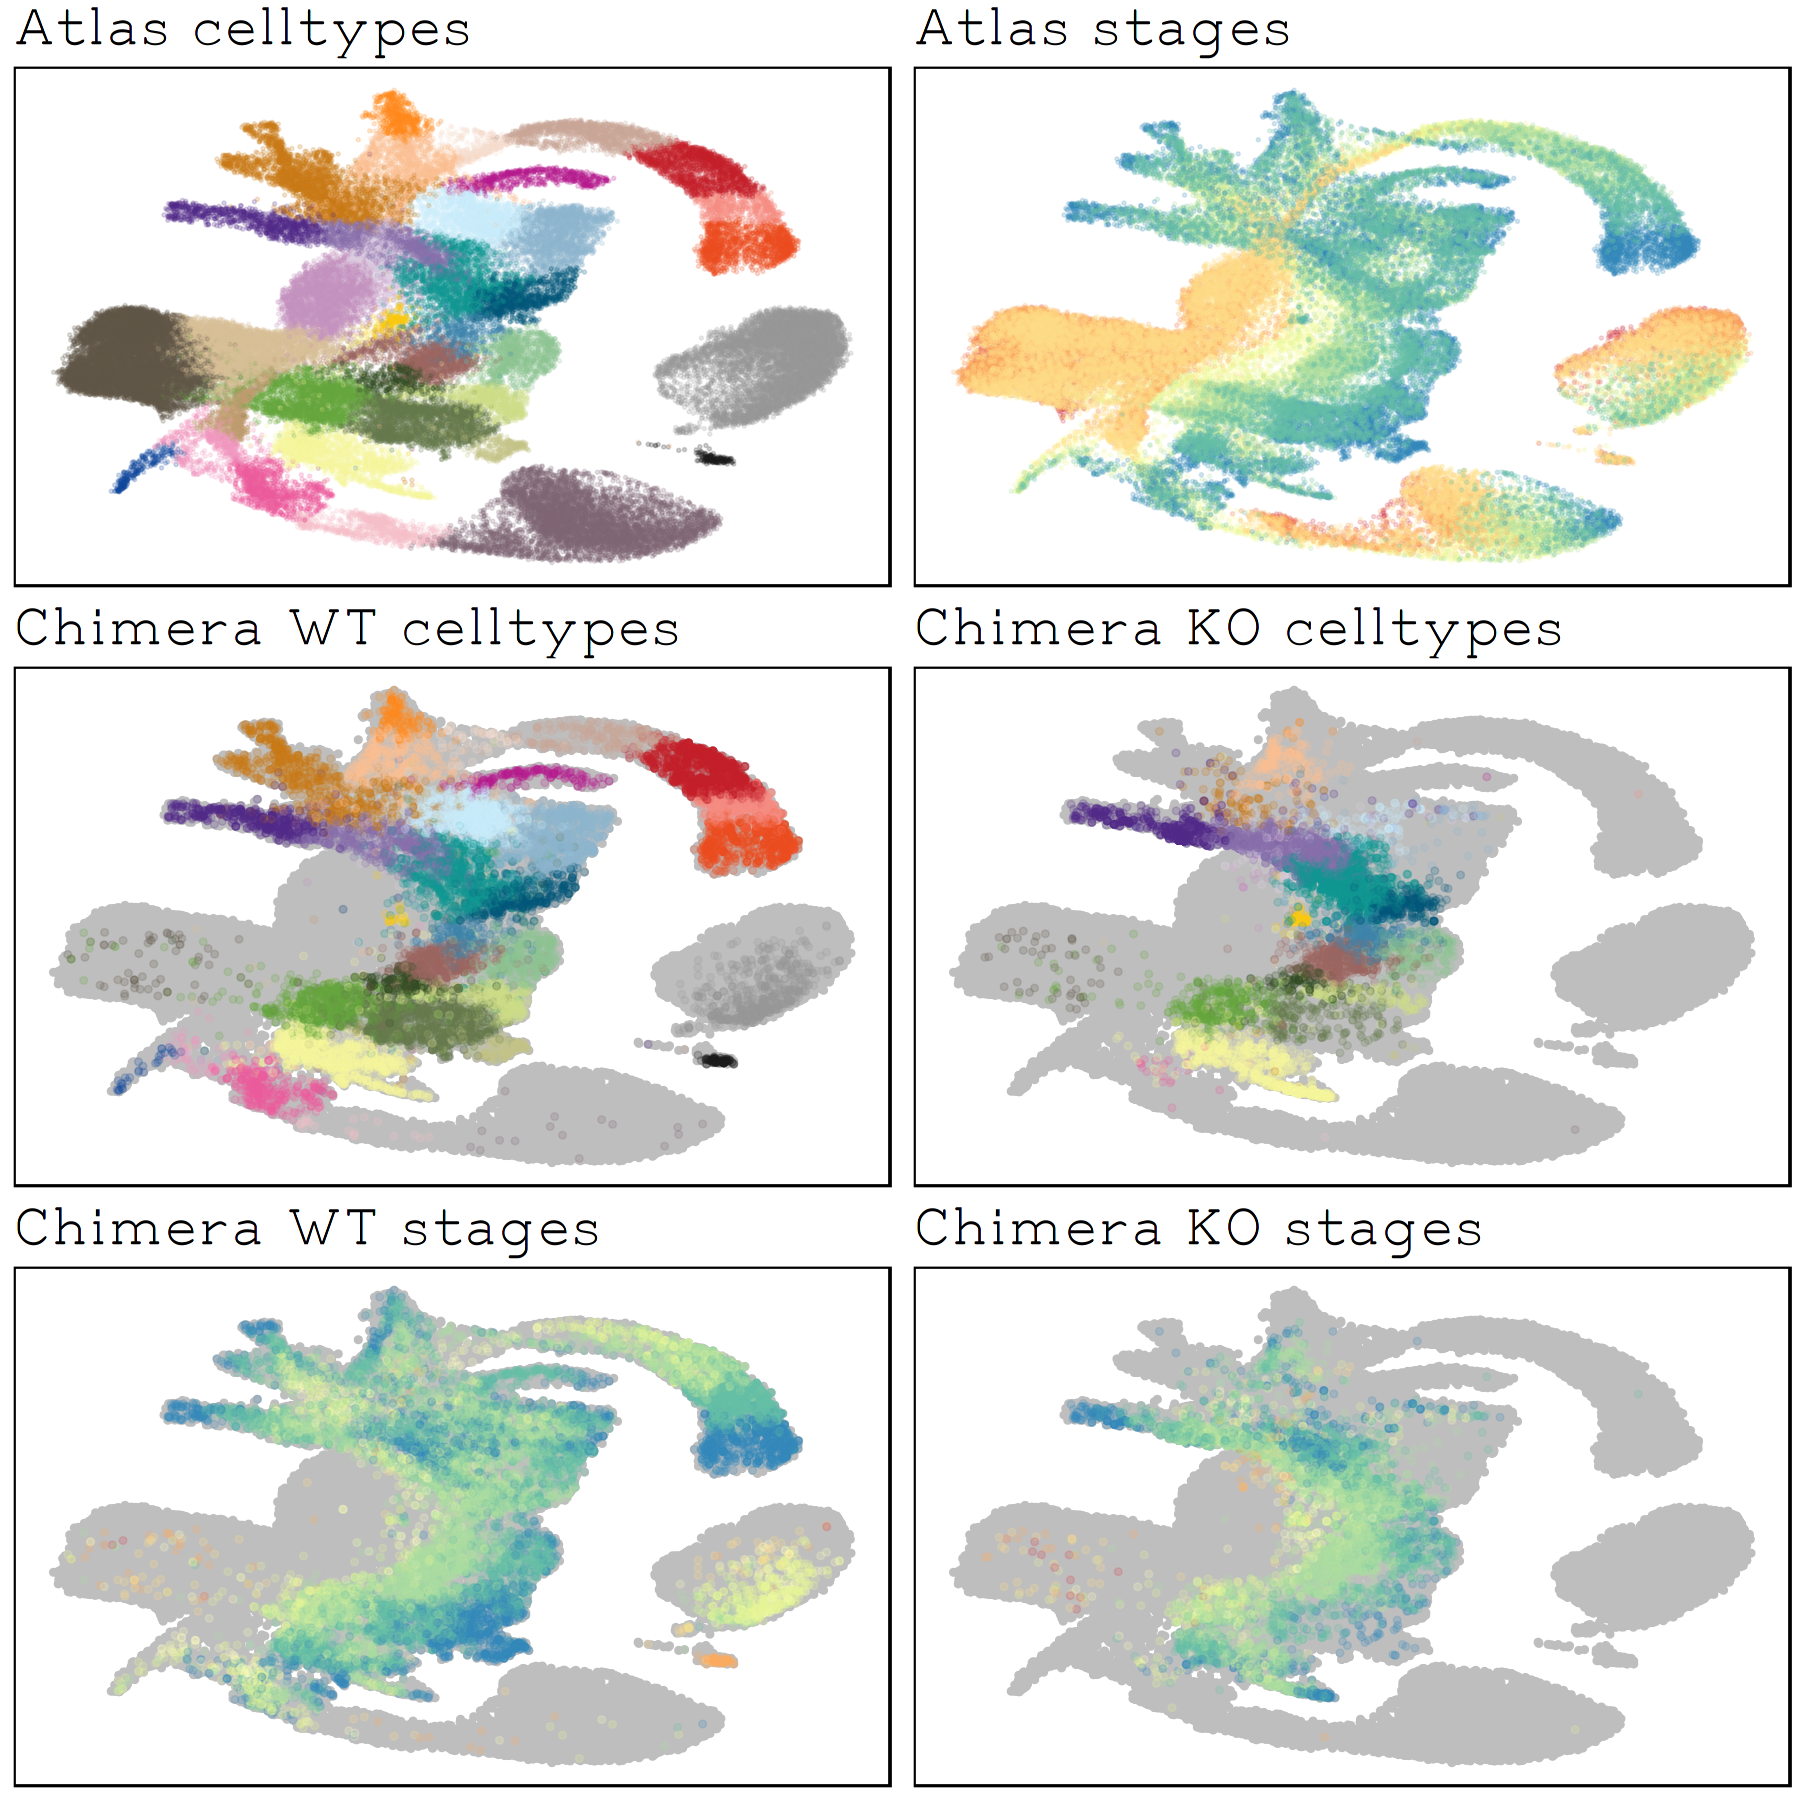

In [138]:
p1 = ggplot(atlas_meta, aes(umapX, umapY, col=celltype)) + 
    geom_point(alpha=0.2, size = 0.5) + 
    ggtitle('Atlas celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p2 = ggplot(atlas_meta, aes(umapX, umapY, col=stage)) + 
    geom_point(alpha=0.2, size = 0.5) + 
    ggtitle('Atlas stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

p3 = ggplot(mappings[mappings$tdTom=='negative',], aes(umapX, umapY, col=mappings[mappings$tdTom=='negative',]$celltype.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera WT celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p4 = ggplot(mappings[mappings$tdTom=='positive',], aes(umapX, umapY, col=mappings[mappings$tdTom=='positive',]$celltype.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera KO celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p5 = ggplot(mappings[mappings$tdTom=='negative',], aes(umapX, umapY, col=mappings[mappings$tdTom=='negative',]$stage.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera WT stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

p6 = ggplot(mappings[mappings$tdTom=='positive',], aes(umapX, umapY, col=mappings[mappings$tdTom=='positive',]$stage.mapped)) +
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera KO stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

options(repr.plot.width=15, repr.plot.height=15)
grid.arrange(p1, p2, p3, p4, p5, p6, ncol=2)

In [140]:
# add plots for mapping scores!!

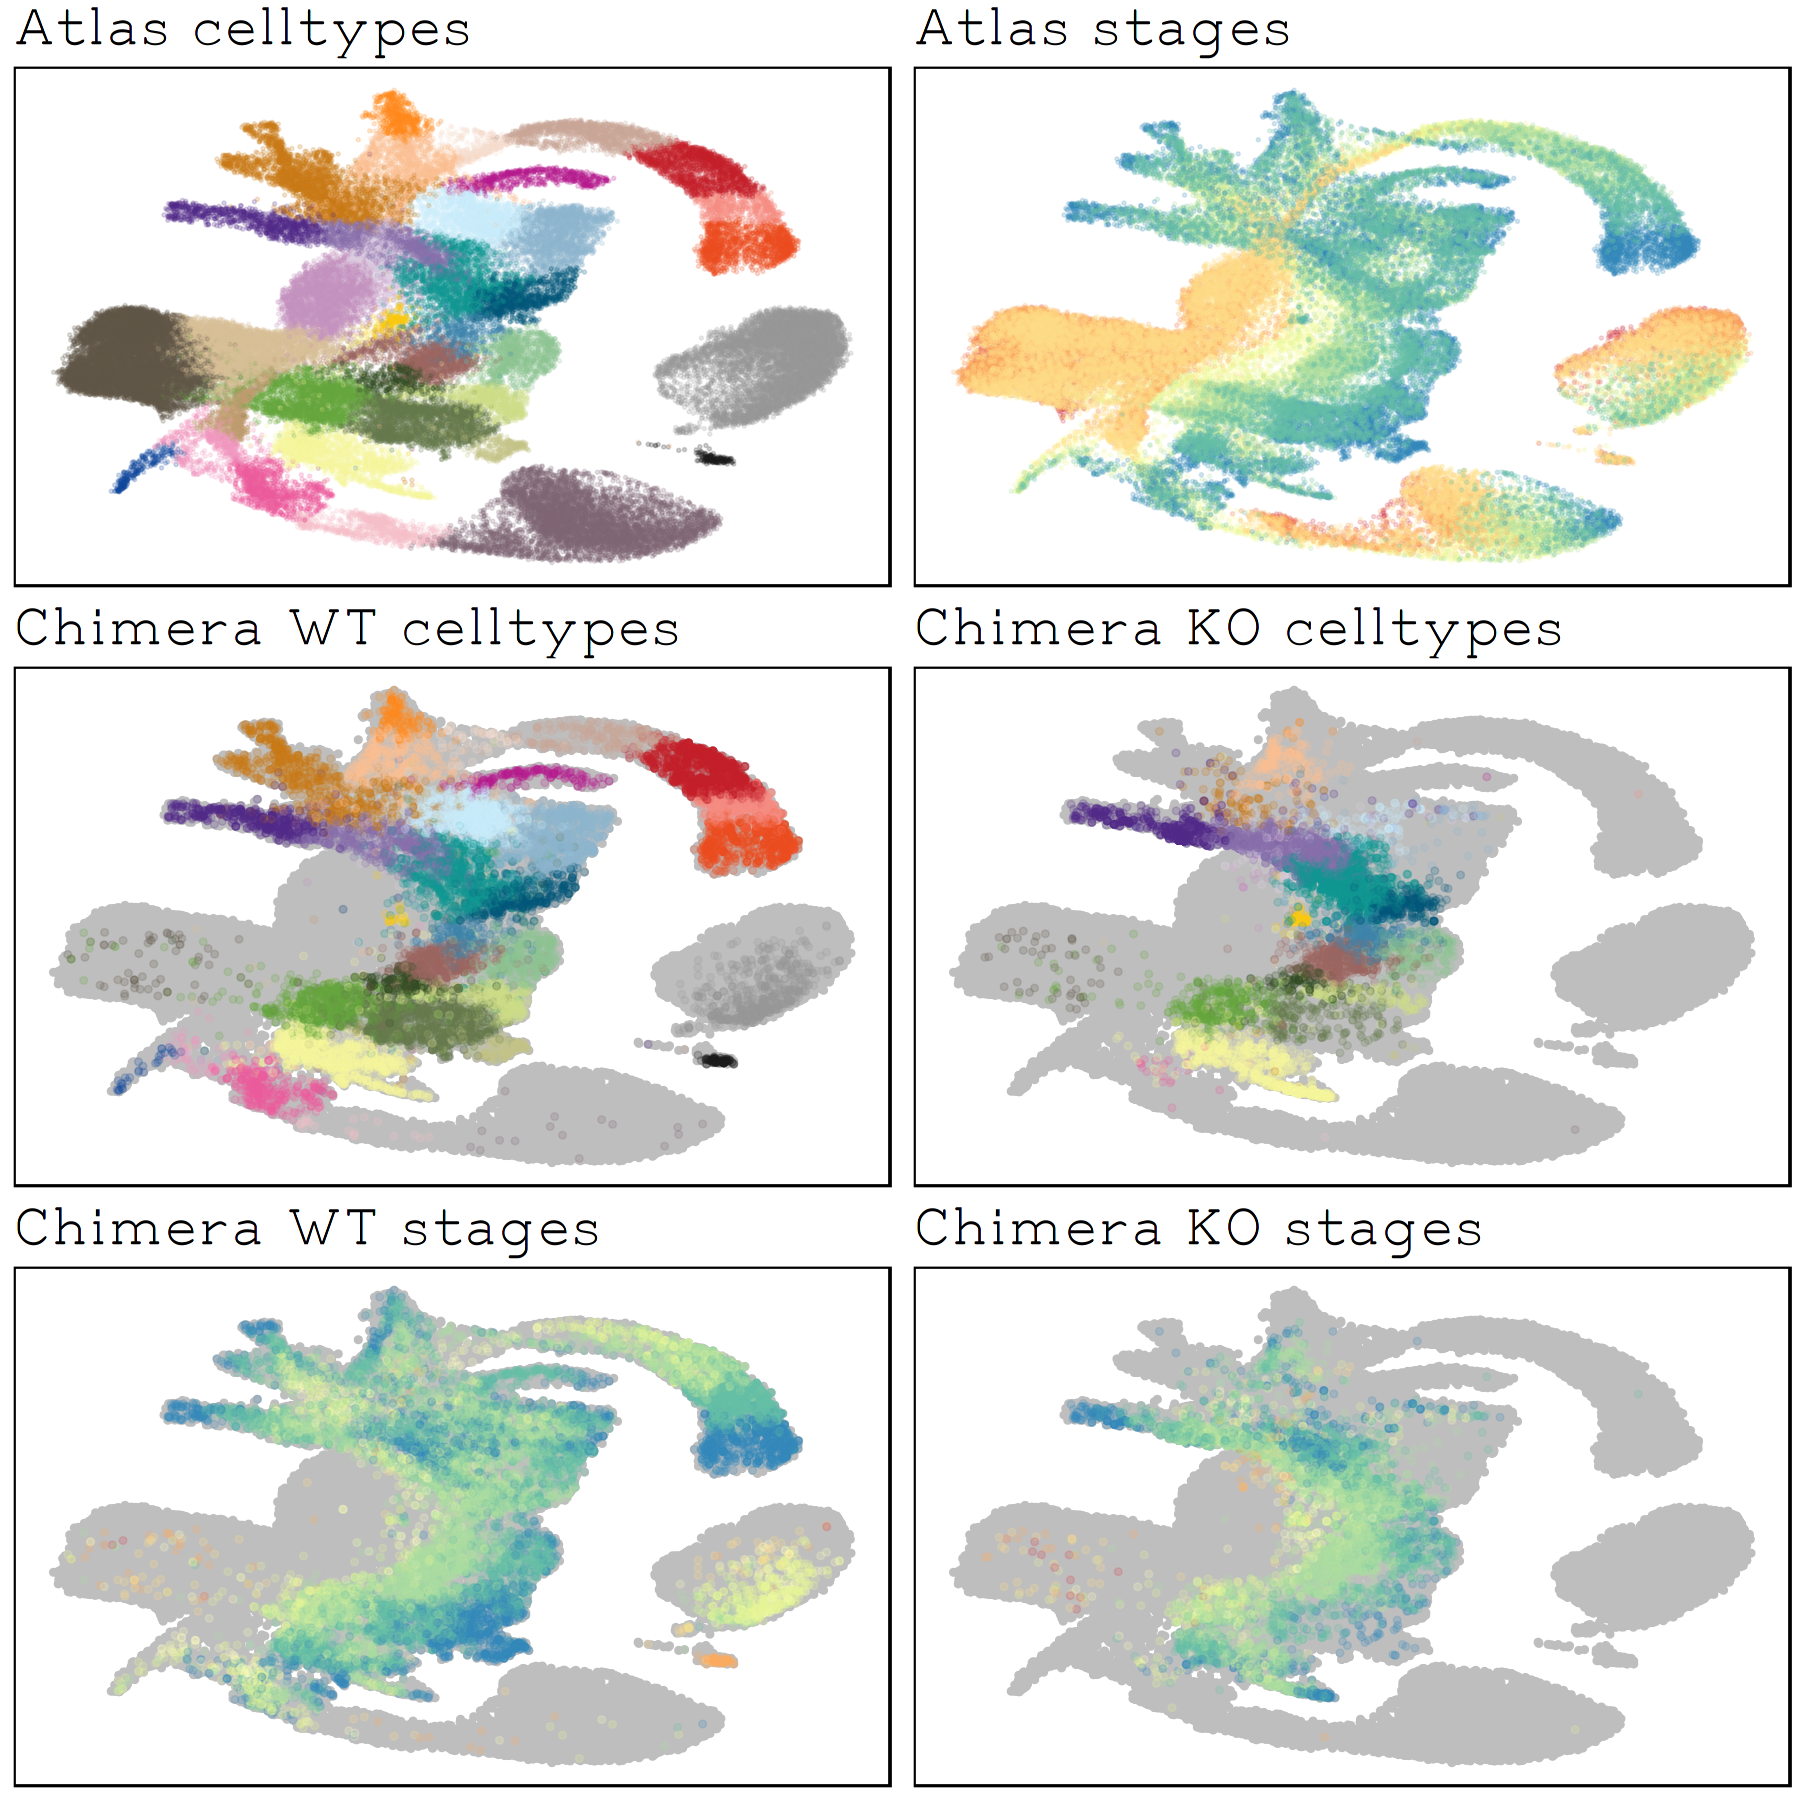

In [139]:
ggsave(paste0(plot_dir, 'Atlas_projection.png'), 
       plot = grid.arrange(p1, p2, p3, p4, p5, p6, ncol=2), 
       device = 'png',
       width = 12,
       height = 15,
       dpi = 300)